# 01. CZ gate — validation & error budget

两体 Rydberg CZ 门的验证与误差预算。两个 Part 各自自包含。

- **Part A — CZ validation & error budget(`our` 7-level)**:TO/AR 优化门 baseline fidelity、dark-detuning 相位结构、SSS population、deterministic + Monte Carlo 误差预算(默认读缓存 / `RUN_*=False` dry-run)。
- **Part B — Saffman double-ARP(exact 验证)**:exact backend 复现 Saffman 对称 double-ARP CZ(01r 两原子)——pulse、population cycle、Bell fidelity、鲁棒性扫描;并把同一 ARP 映射到 `our` 7-level + 动态 Stark 诊断。

合并自 `cz_gate_validation_and_errors` + `01r_saffman_double_arp_exact`。

## Part A — CZ validation & error budget(`our` 7-level)

确认优化后的 CZ 门本身高保真,再看 population dynamics,最后把 infidelity 按物理来源拆开(确定性 + Monte Carlo)——区分"门 protocol 不对"与"物理误差源导致 infidelity"。

## 0. Notebook setup

定位 repo root、把 `src/` 加入 `sys.path`、强制 JAX 用 CPU。所有 system 直接用 `RydbergSystem.from_lattice(...)` 构造。

In [2]:
from pathlib import Path
import os
import sys
import json

os.environ.setdefault("JAX_PLATFORMS", "cpu")

HERE = Path.cwd().resolve()
if HERE.name == "notebooks":
    REPO_ROOT = HERE.parents[1]
elif HERE.name == "scripts":
    REPO_ROOT = HERE.parent
else:
    REPO_ROOT = HERE
os.chdir(REPO_ROOT)

src_path = REPO_ROOT / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, IFrame
from scipy.optimize import curve_fit

from ryd_gate import RydbergSystem
from ryd_gate.lattice import Register
from ryd_gate.analysis.gate_metrics import (
    average_gate_infidelity,
    sss_infidelity,
    population_evolution,
    state_infidelity,
    error_budget,
    residuals_to_branching,
)
from ryd_gate.backends.exact import simulate, MonteCarloResult, MonteCarloRunner
from ryd_gate.protocols.gate_cz import ARProtocol
from ryd_gate.protocols.gate_cz import TOProtocol

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})
print(f"Repo root: {REPO_ROOT}")


Repo root: /home/chance/Ryd-gate-modeling


优化门参数

In [ ]:
# TO-parameter re-optimization on the current kernel API.
# Optimization workflows live in scripts/ (see scripts/optimize_ar_cz.py for the
# AR analogue); this cell keeps the inline TO variant. Flip the flag to re-run —
# a full Nelder-Mead search costs hours of exact-solver time.
RUN_TO_OPTIMIZATION = False

x0 = [
    0.6246672641243727,
    1.2369507331752663,
    -0.470787497434612,
    1.6547386752699043,
    3.41960305947842,
    1.3338111168065905,
]

if RUN_TO_OPTIMIZATION:
    from scipy.optimize import minimize

    system_opt = RydbergSystem.from_lattice(
        Register.chain(2, spacing_um=3.0), "rb87_7", param_set="our",
        blackmanflag=True, detuning_sign=-1,
    )
    protocol_opt = TOProtocol()
    print("initial:", average_gate_infidelity(system_opt, protocol_opt, x0))
    res = minimize(
        lambda x: float(average_gate_infidelity(system_opt, protocol_opt, list(x))),
        x0, method="Nelder-Mead", options={"fatol": 1e-9, "disp": True},
    )
    print(res.fun)
    print(res.x.tolist())
else:
    print("Skipped TO re-optimization (set RUN_TO_OPTIMIZATION=True to run).")


## 1. Baseline CZ gate fidelity

打开误差预算前,先算 TO(dark/bright)和 AR 两类 protocol 的 average gate infidelity,确认优化参数本身能实现高保真 CZ(把 control waveform 与 decay/position 等物理误差分开)。

In [3]:
# Optimized TO parameters used consistently in this notebook.
# x = [A, omega/Omega_eff, phi0, delta/Omega_eff, theta, T/T_scale]
X_TO_DARK = [
    -0.6989301339711643,
    1.0296229082590798,
    0.3759232324550267,
    1.5710180991068543,
    1.4454279613697887,
    1.3406239758422793,
]
X_TO_BRIGHT = [
    0.6246672641243727,
    1.2369507331752663,
    -0.470787497434612,
    1.6547386752699043,
    3.41960305947842,
    1.3338111168065905,
]
X_AR = [0.85973359, 0.39146974, 0.99181418, 0.1924498, -1.17123748, -0.00826712, 1.67429728, 0.28527346]

protocol_to = TOProtocol()
protocol_ar = ARProtocol()

system_dark = RydbergSystem.from_lattice(Register.chain(2, spacing_um=3.0), "rb87_7", param_set="our", blackmanflag=True, detuning_sign=1)
system_bright = RydbergSystem.from_lattice(Register.chain(2, spacing_um=3.0), "rb87_7", param_set="our", blackmanflag=True, detuning_sign=-1)
system_plain = RydbergSystem.from_lattice(Register.chain(2, spacing_um=3.0), "rb87_7", param_set="our")

rows = []
rows.append(("TO", "dark detuning", average_gate_infidelity(system_dark, protocol_to, X_TO_DARK)))
rows.append(("TO", "bright detuning", average_gate_infidelity(system_bright, protocol_to, X_TO_BRIGHT)))
rows.append(("AR", "plain our system", average_gate_infidelity(system_plain, protocol_ar, X_AR)))

text = "| protocol | system | average infidelity |\n|---|---:|---:|\n"
for proto, label, val in rows:
    text += f"| {proto} | {label} | {val:.6e} |\n"
display(Markdown(text))


| protocol | system | average infidelity |
|---|---:|---:|
| TO | dark detuning | 7.803243e-07 |
| TO | bright detuning | 5.267349e-01 |
| AR | plain our system | 5.764713e-01 |


## 2. Dark-detuning CZ phase structure

令 `theta=0` 看 raw evolution:计算基态应基本返回自身、只积累相位。扣掉单比特 Z 相位后 `|11>` 相对 `|00>` 应多出约 `π` 的 CZ 相位、leakage 小——确认是真正的 controlled-phase,而非平均 fidelity 好看。

In [3]:
theta = X_TO_DARK[4]
x_no_theta = list(X_TO_DARK)
x_no_theta[4] = 0.0

basis = {label: system_dark.product_state(label) for label in ("00", "01", "10", "11")}
compiled_system = system_dark.with_protocol(protocol_to)

overlaps = {}
phase_rows = []
for label, psi0 in basis.items():
    psi_f = simulate(compiled_system, x_no_theta, psi0).psi_final
    overlap = np.vdot(psi0, psi_f)
    overlaps[label] = overlap

    comp_pop = 0.0
    for other in basis.values():
        comp_pop += abs(np.vdot(other, psi_f)) ** 2
    leakage = 1.0 - comp_pop
    phase_rows.append((label, abs(overlap) ** 2, np.angle(overlap), leakage))

phi00 = np.angle(overlaps["00"])
phi01 = np.angle(overlaps["01"])
phi10 = np.angle(overlaps["10"])
phi11 = np.angle(overlaps["11"])
cz_phase = phi11 - 2 * theta - phi00
cz_phase = (cz_phase + np.pi) % (2 * np.pi) - np.pi

text = "| input | return probability | raw phase (rad) | leakage |\n|---|---:|---:|---:|\n"
for label, pop, phase, leakage in phase_rows:
    text += f"| `{label}` | {pop:.10f} | {phase:+.6f} | {leakage:.3e} |\n"
text += "\n"
text += f"Single-qubit Z theta = `{theta:.6f}` rad.  \n"
text += f"CZ phase after removing Z rotations = `{cz_phase:+.6f}` rad.  \n"
text += f"Distance from ±π = `{abs(abs(cz_phase) - np.pi):.4e}` rad."
display(Markdown(text))


| input | return probability | raw phase (rad) | leakage |
|---|---:|---:|---:|
| `00` | 1.0000000000 | +2.724094 | 0.000e+00 |
| `01` | 0.9999992464 | -2.112920 | 7.536e-07 |
| `10` | 0.9999992464 | -2.112920 | 7.536e-07 |
| `11` | 0.9999990959 | +2.474685 | 9.041e-07 |

Single-qubit Z theta = `1.445428` rad.  
CZ phase after removing Z rotations = `-3.140265` rad.  
Distance from ±π = `1.3275e-03` rad.

## 3. SSS population evolution(Schrodinger)

对 12 个 SSS 初态画 intermediate / 目标 Rydberg / garbage Rydberg population。intermediate 只在 pulse 中短暂出现、末态 leakage 小;intermediate population 越高,后面的 intermediate-decay budget 越大。

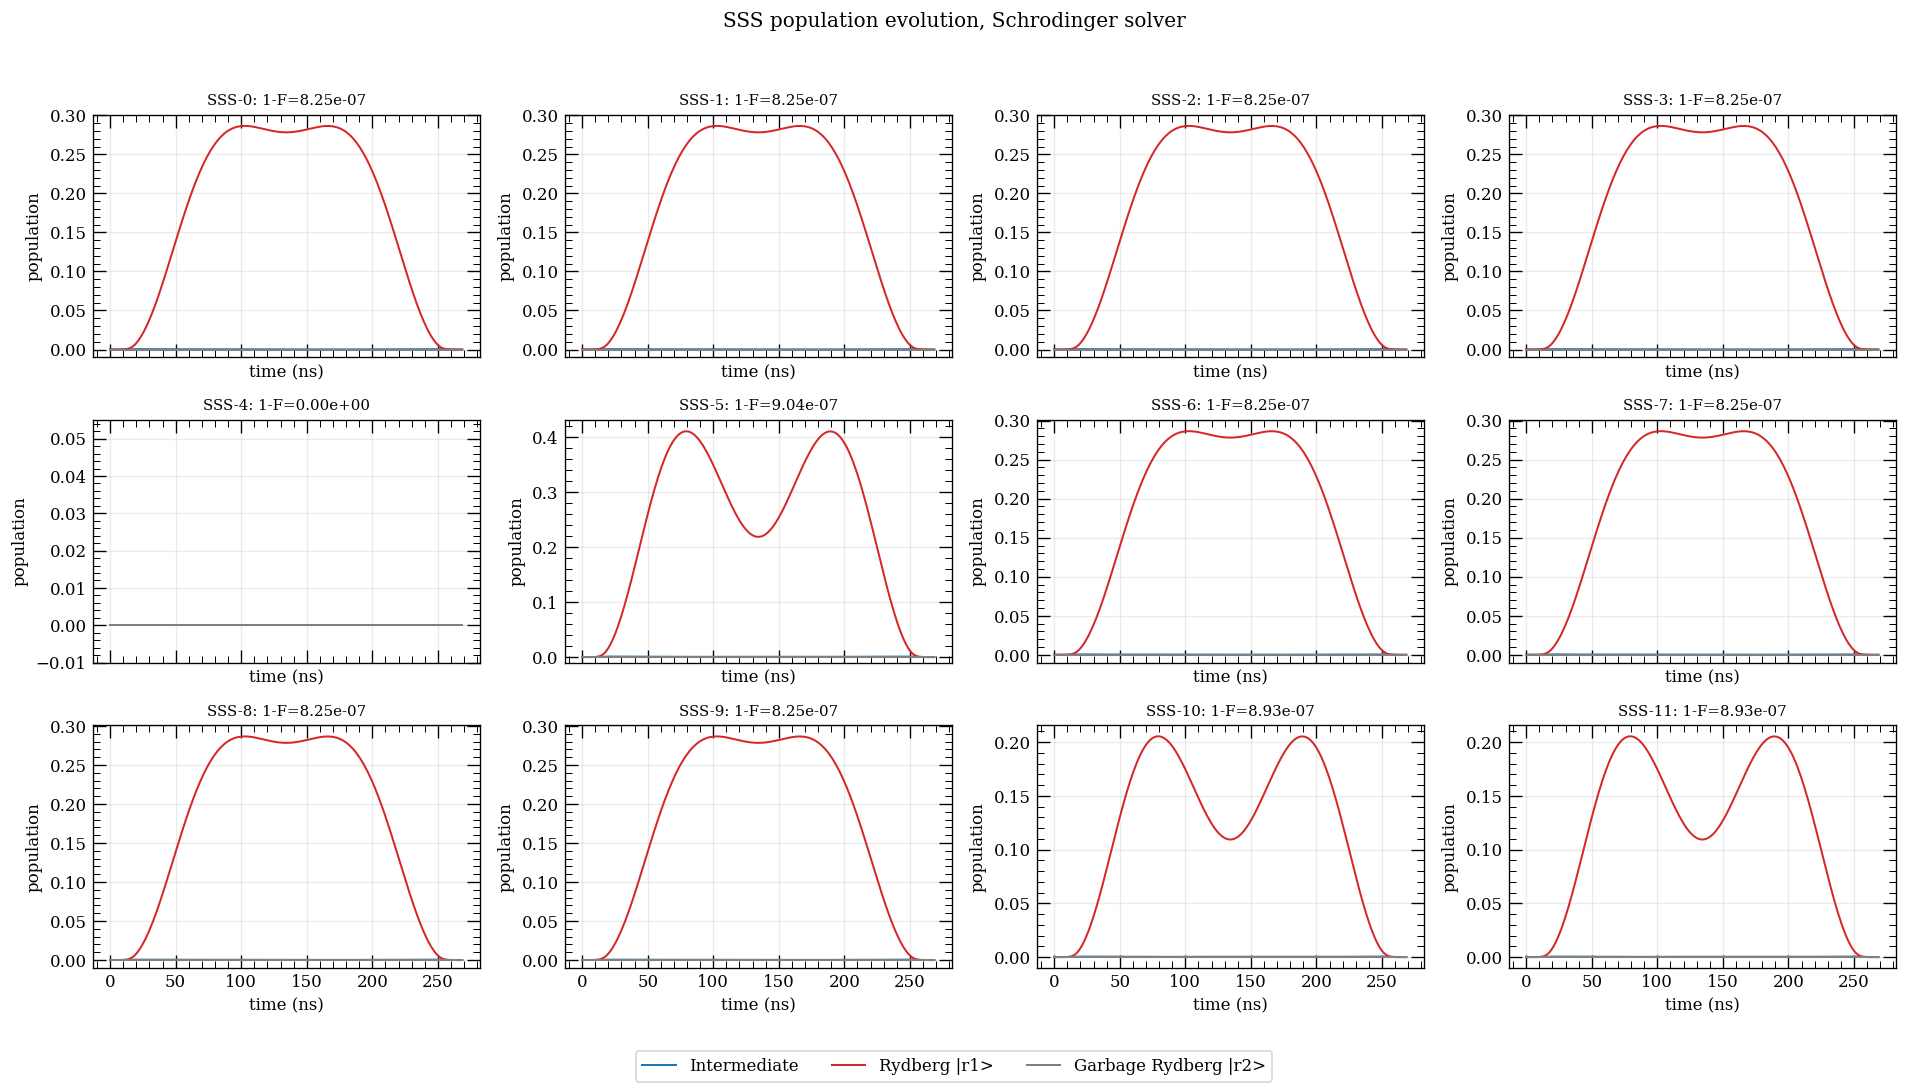

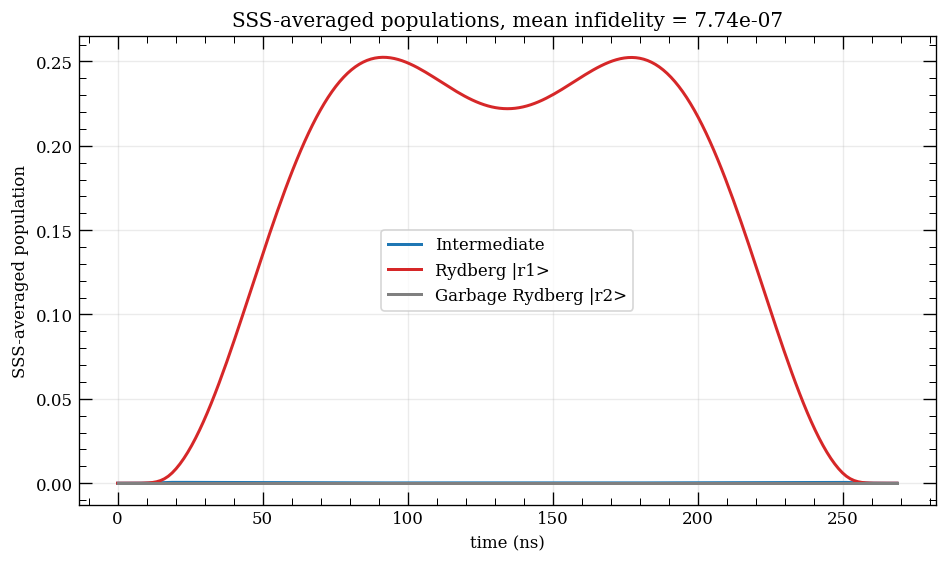

In [4]:
N_SSS = 12
categories = ["Intermediate", "Rydberg |r1>", "Garbage Rydberg |r2>"]
colors = {"Intermediate": "tab:blue", "Rydberg |r1>": "tab:red", "Garbage Rydberg |r2>": "gray"}

# population_evolution returns the times the exact backend actually recorded (the sparse
# piecewise backend stores one point per protocol step), so size the arrays from the
# returned t_list rather than hardcoding the sample count.
results = [population_evolution(system_dark, protocol_to, X_TO_DARK, f"SSS-{i}") for i in range(N_SSS)]
time_ns = np.asarray(results[0]["t_list"]) * 1e9
N_TIME = time_ns.size
pops = np.zeros((N_SSS, 3, N_TIME))
infidelities = np.zeros(N_SSS)
for i, result in enumerate(results):
    pops[i, 0, :] = (result["e1"] + result["e2"] + result["e3"]) / 2.0
    pops[i, 1, :] = result["ryd"] / 2.0
    pops[i, 2, :] = result["ryd_garb"] / 2.0
    infidelities[i] = state_infidelity(system_dark, protocol_to, X_TO_DARK, f"SSS-{i}")

fig, axes = plt.subplots(3, 4, figsize=(16, 9), sharex=True)
for i, ax in enumerate(axes.flat):
    for c, cat in enumerate(categories):
        ax.plot(time_ns, pops[i, c], lw=1.2, color=colors[cat], label=cat)
    ax.set_title(f"SSS-{i}: 1-F={infidelities[i]:.2e}", fontsize=9)
    ax.set_ylim(bottom=-0.01)
    ax.set_xlabel("time (ns)")
    ax.set_ylabel("population")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3)
fig.suptitle("SSS population evolution, Schrodinger solver", y=0.995)
fig.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.8))
for c, cat in enumerate(categories):
    ax.plot(time_ns, pops[:, c, :].mean(axis=0), lw=1.8, color=colors[cat], label=cat)
ax.set_title(f"SSS-averaged populations, mean infidelity = {infidelities.mean():.2e}")
ax.set_xlabel("time (ns)")
ax.set_ylabel("SSS-averaged population")
ax.legend()
fig.tight_layout()
plt.show()


## 4. Deterministic error budget

逐个打开 Rydberg decay / intermediate decay / polarization leakage,给出 infidelity 与 XYZ/AL/LG 分解,判断哪类不可逆过程主导门误差。默认读 `data/det_dark.json` 缓存,缺失则重算。

In [5]:
USE_CACHED_DETERMINISTIC = True
SSS_12_STATES = [f"SSS-{i}" for i in range(12)]
det_path = REPO_ROOT / "data" / "det_dark.json"
if USE_CACHED_DETERMINISTIC and det_path.exists():
    text = det_path.read_text()
    json_lines = [line for line in text.splitlines() if not line.startswith("#")]
    det = json.loads("\n".join(json_lines))
    print(f"Loaded deterministic cache: {det_path}")
else:
    det = {}
    protocol = TOProtocol()

    system_ryd = RydbergSystem.from_lattice(Register.chain(2, spacing_um=3.0), "rb87_7", param_set="our", blackmanflag=True, detuning_sign=1, enable_rydberg_decay=True)
    budget_ryd = error_budget(system_ryd, protocol, X_TO_DARK, initial_states=SSS_12_STATES)
    det["rydberg_decay"] = {"infidelity": sss_infidelity(system_ryd, protocol, X_TO_DARK), **budget_ryd["rydberg_decay"]}

    system_mid = RydbergSystem.from_lattice(Register.chain(2, spacing_um=3.0), "rb87_7", param_set="our", blackmanflag=True, detuning_sign=1, enable_intermediate_decay=True)
    budget_mid = error_budget(system_mid, protocol, X_TO_DARK, initial_states=SSS_12_STATES)
    det["intermediate_decay"] = {"infidelity": sss_infidelity(system_mid, protocol, X_TO_DARK), **budget_mid["intermediate_decay"]}

    system_mid_no0 = RydbergSystem.from_lattice(
        Register.chain(2, spacing_um=3.0),
        "rb87_7",
        param_set="our",
        blackmanflag=True,
        detuning_sign=1,
        enable_intermediate_decay=True,
        enable_0_scattering=False,
    )
    det["scattering_0_extra_infidelity"] = max(
        0.0,
        det["intermediate_decay"]["infidelity"] - sss_infidelity(system_mid_no0, protocol, X_TO_DARK),
    )

    system_pol = RydbergSystem.from_lattice(Register.chain(2, spacing_um=3.0), "rb87_7", param_set="our", blackmanflag=True, detuning_sign=1, enable_polarization_leakage=True)
    budget_pol = error_budget(system_pol, protocol, X_TO_DARK, initial_states=SSS_12_STATES)
    det["polarization_leakage"] = {"infidelity": sss_infidelity(system_pol, protocol, X_TO_DARK), **budget_pol["polarization_leakage"]}

    system_all = RydbergSystem.from_lattice(
        Register.chain(2, spacing_um=3.0),
        "rb87_7",
        param_set="our",
        blackmanflag=True,
        detuning_sign=1,
        enable_rydberg_decay=True,
        enable_intermediate_decay=True,
        enable_polarization_leakage=True,
    )
    budget_all = error_budget(system_all, protocol, X_TO_DARK, initial_states=SSS_12_STATES)
    det["all_deterministic"] = {
        "infidelity": sss_infidelity(system_all, protocol, X_TO_DARK),
        "XYZ": budget_all["rydberg_decay"]["XYZ"] + budget_all["intermediate_decay"]["XYZ"] + budget_all["polarization_leakage"]["XYZ"],
        "AL": budget_all["rydberg_decay"]["AL"] + budget_all["intermediate_decay"]["AL"] + budget_all["polarization_leakage"]["AL"],
        "LG": budget_all["rydberg_decay"]["LG"] + budget_all["intermediate_decay"]["LG"] + budget_all["polarization_leakage"]["LG"],
    }

text = "| source | infidelity | XYZ | AL | LG | coherent/phase residual |\n|---|---:|---:|---:|---:|---:|\n"
for key in ("rydberg_decay", "intermediate_decay", "polarization_leakage", "all_deterministic"):
    e = det[key]
    xyz = e.get("XYZ")
    al = e.get("AL")
    lg = e.get("LG")
    if xyz is None:
        text += f"| {key} | {e['infidelity']:.6e} | - | - | - | - |\n"
    else:
        residual = e["infidelity"] - (xyz + al + lg)
        if key == "intermediate_decay" and "scattering_0_extra_infidelity" in det:
            residual -= det["scattering_0_extra_infidelity"]
        text += f"| {key} | {e['infidelity']:.6e} | {xyz:.6e} | {al:.6e} | {lg:.6e} | {residual:.6e} |\n"
if "scattering_0_extra_infidelity" in det:
    text += f"\nIntermediate `|0>` scattering extra infidelity: `{det['scattering_0_extra_infidelity']:.6e}`."
display(Markdown(text))


Loaded deterministic cache: /home/chance/Ryd-gate-modeling/data/det_dark.json


| source | infidelity | XYZ | AL | LG | coherent/phase residual |
|---|---:|---:|---:|---:|---:|
| rydberg_decay | 5.521083e-04 | 8.694386e-05 | 3.482160e-04 | 1.169165e-04 | 3.189524e-08 |
| intermediate_decay | 1.850410e-03 | 5.063159e-04 | 0.000000e+00 | 6.533187e-04 | 3.582410e-07 |
| polarization_leakage | 7.158679e-05 | 4.369242e-08 | 1.752348e-05 | 5.875475e-08 | 5.396087e-05 |
| all_deterministic | 2.475912e-03 | 5.939197e-04 | 3.741466e-04 | 7.713500e-04 | 7.364961e-04 |

Intermediate `|0>` scattering extra infidelity: `6.904172e-04`.

## 5. Monte Carlo noise and branching

detuning noise / position noise / all-errors 的 Monte Carlo:total infidelity 均值±标准误,以及 XYZ/AL/LG/phase branch 贡献,与确定性 decay 放在同一误差语言下比较。默认读 `data/mc_dark_*.txt`,`RUN_MONTE_CARLO=True` 重算。

In [6]:
RUN_MONTE_CARLO = False
N_MC = 500
MC_SEED = 42
mc = {}

for key in ("dephasing", "position", "all"):
    path = REPO_ROOT / "data" / f"mc_dark_{key}.txt"
    if path.exists():
        mc[key] = MonteCarloResult.load_from_file(path)
        print(f"Loaded {key}: {path}")

if RUN_MONTE_CARLO:
    sigma_pos = (70e-9, 70e-9, 130e-9)
    protocol = TOProtocol()

    system_deph = RydbergSystem.from_lattice(Register.chain(2, spacing_um=3.0), "rb87_7", param_set="our", blackmanflag=True, detuning_sign=1)
    engine = MonteCarloRunner(system_deph.with_protocol(protocol), X_TO_DARK)
    engine.setup_detuning_noise(130e3)
    mc["dephasing"] = engine.run_gate_fidelity(n_shots=N_MC, seed=MC_SEED, compute_branching=True)

    system_pos = RydbergSystem.from_lattice(Register.chain(2, spacing_um=3.0), "rb87_7", param_set="our", blackmanflag=True, detuning_sign=1)
    engine = MonteCarloRunner(system_pos.with_protocol(protocol), X_TO_DARK)
    engine.setup_position_noise(sigma_pos)
    mc["position"] = engine.run_gate_fidelity(n_shots=N_MC, seed=MC_SEED + 1, compute_branching=True)

    system_all = RydbergSystem.from_lattice(
        Register.chain(2, spacing_um=3.0),
        "rb87_7",
        param_set="our",
        blackmanflag=True,
        detuning_sign=1,
        enable_rydberg_decay=True,
        enable_intermediate_decay=True,
        enable_polarization_leakage=True,
    )
    engine = MonteCarloRunner(system_all.with_protocol(protocol), X_TO_DARK)
    engine.setup_detuning_noise(130e3)
    engine.setup_position_noise(sigma_pos)
    mc["all"] = engine.run_gate_fidelity(n_shots=N_MC, seed=MC_SEED + 2, compute_branching=True)

if mc:
    def _fmt(v):
        return f"{v:.6e}" if v is not None else "—"
    text = "| scenario | shots | mean infidelity | SEM | XYZ | AL | LG | phase |\n|---|---:|---:|---:|---:|---:|---:|---:|\n"
    for key, result in mc.items():
        sem = result.std_infidelity / np.sqrt(result.n_shots)
        text += (
            f"| {key} | {result.n_shots} | {result.mean_infidelity:.6e} | {sem:.2e} | "
            f"{_fmt(result.mean_branch_XYZ)} | {_fmt(result.mean_branch_AL)} | "
            f"{_fmt(result.mean_branch_LG)} | {_fmt(result.mean_branch_phase)} |\n"
        )
    display(Markdown(text))
else:
    print("No MC cache found. Set RUN_MONTE_CARLO=True to generate results.")


Loaded dephasing: /home/chance/Ryd-gate-modeling/data/mc_dark_dephasing.txt
Loaded position: /home/chance/Ryd-gate-modeling/data/mc_dark_position.txt
Loaded all: /home/chance/Ryd-gate-modeling/data/mc_dark_all.txt


| scenario | shots | mean infidelity | SEM | XYZ | AL | LG | phase |
|---|---:|---:|---:|---:|---:|---:|---:|
| dephasing | 1000 | 1.942413e-03 | 8.83e-05 | — | — | — | — |
| position | 1000 | 4.623568e-07 | 2.18e-08 | — | — | — | — |
| all | 1000 | 4.487244e-03 | 9.62e-05 | — | — | — | — |


## 6. SI-style combined table

把确定性、stochastic、combined 误差合成一张 Markdown 表(error budget 摘要)。

In [7]:
if "det" in globals() and "mc" in globals() and mc:
    def _fmt(v):
        return f"{v:.6e}" if v is not None else "—"
    text = "| group | source | infidelity | XYZ | AL | LG | coh/phase |\n|---|---|---:|---:|---:|---:|---:|\n"
    for key in ("rydberg_decay", "intermediate_decay", "polarization_leakage", "all_deterministic"):
        e = det[key]
        xyz, al, lg = e.get("XYZ"), e.get("AL"), e.get("LG")
        residual = e["infidelity"] - (xyz + al + lg) if xyz is not None else np.nan
        if key == "intermediate_decay" and "scattering_0_extra_infidelity" in det:
            residual -= det["scattering_0_extra_infidelity"]
        text += f"| deterministic | {key} | {e['infidelity']:.6e} | {_fmt(xyz)} | {_fmt(al)} | {_fmt(lg)} | {_fmt(residual)} |\n"
    for key in ("dephasing", "position", "all"):
        if key not in mc:
            continue
        r = mc[key]
        text += (
            f"| Monte Carlo | {key} | {r.mean_infidelity:.6e} ± {r.std_infidelity / np.sqrt(r.n_shots):.2e} | "
            f"{_fmt(r.mean_branch_XYZ)} | {_fmt(r.mean_branch_AL)} | {_fmt(r.mean_branch_LG)} | {_fmt(r.mean_branch_phase)} |\n"
        )
    display(Markdown(text))
else:
    print("Run/load deterministic and MC blocks first.")


| group | source | infidelity | XYZ | AL | LG | coh/phase |
|---|---|---:|---:|---:|---:|---:|
| deterministic | rydberg_decay | 5.521083e-04 | 8.694386e-05 | 3.482160e-04 | 1.169165e-04 | 3.189524e-08 |
| deterministic | intermediate_decay | 1.850410e-03 | 5.063159e-04 | 0.000000e+00 | 6.533187e-04 | 3.582410e-07 |
| deterministic | polarization_leakage | 7.158679e-05 | 4.369242e-08 | 1.752348e-05 | 5.875475e-08 | 5.396087e-05 |
| deterministic | all_deterministic | 2.475912e-03 | 5.939197e-04 | 3.741466e-04 | 7.713500e-04 | 7.364961e-04 |
| Monte Carlo | dephasing | 1.942413e-03 ± 8.83e-05 | — | — | — | — |
| Monte Carlo | position | 4.623568e-07 ± 2.18e-08 | — | — | — | — |
| Monte Carlo | all | 4.487244e-03 ± 9.62e-05 | — | — | — | — |


## 7. Advanced: Gaussian sensitivity & iso-fidelity decomposition

单参数 Gaussian waist fit → sigma-normalized simultaneous sensitivity → iso-fidelity surface 分解:优化点附近哪些 control 参数最敏感、误差增长主要落到哪类 branch。耗时(约数小时),默认 `RUN_LONG_SENSITIVITY=False`。

In [8]:
RUN_LONG_SENSITIVITY = False

# This block is the notebook-native version of the former sensitivity script.
# It is intentionally linear rather than hidden behind helper functions: first
# sweep each pulse parameter, then use the fitted widths to probe simultaneous
# shifts and the iso-fidelity surface.
if RUN_LONG_SENSITIVITY:
    X_SENS = list(X_TO_DARK)
    PARAM_NAMES = {
        0: "A (cosine amplitude)",
        1: "omega/Omega_eff (mod. freq.)",
        2: "phi0 (initial phase)",
        3: "delta/Omega_eff (chirp rate)",
        5: "T/T_scale (gate time)",
    }
    PARAM_INDICES = [0, 1, 2, 3, 5]
    N_SWEEP_POINTS = 51
    INFIDELITY_CEILING = 0.01
    INITIAL_HALF_WIDTH_ABS = 0.02

    system_sens = RydbergSystem.from_lattice(
        Register.chain(2, spacing_um=3.0), "rb87_7", param_set="our", blackmanflag=True, detuning_sign=1
    )
    protocol_sens = TOProtocol()
    baseline = average_gate_infidelity(system_sens, protocol_sens, X_SENS)
    print(f"Baseline average infidelity: {baseline:.4e}")

    sweep_results = {}
    sigmas = {}
    for idx in PARAM_INDICES:
        p_opt = X_SENS[idx]
        half_width = INITIAL_HALF_WIDTH_ABS
        for _ in range(20):
            x_plus = list(X_SENS)
            x_minus = list(X_SENS)
            x_plus[idx] = p_opt + half_width
            x_minus[idx] = p_opt - half_width
            inf_plus = average_gate_infidelity(system_sens, protocol_sens, x_plus)
            inf_minus = average_gate_infidelity(system_sens, protocol_sens, x_minus)
            if inf_plus >= INFIDELITY_CEILING and inf_minus >= INFIDELITY_CEILING:
                break
            half_width *= 2.0

        p_values = np.linspace(p_opt - half_width, p_opt + half_width, N_SWEEP_POINTS)
        infidelities = []
        for p_value in p_values:
            x = list(X_SENS)
            x[idx] = float(p_value)
            infidelities.append(average_gate_infidelity(system_sens, protocol_sens, x))
        infidelities = np.asarray(infidelities)
        fidelities = 1.0 - infidelities

        f_peak_guess = float(fidelities.max())
        p0_guess = float(p_values[np.argmax(fidelities)])
        threshold = f_peak_guess / np.e
        above = np.where(fidelities > threshold)[0]
        sigma_guess = (p_values[above[-1]] - p_values[above[0]]) / 2.0 if len(above) >= 2 else half_width / 3.0
        try:
            popt, pcov = curve_fit(
                lambda p, f_peak, p0, sigma: f_peak * np.exp(-((p - p0) ** 2) / (2 * sigma**2)),
                p_values,
                fidelities,
                p0=[f_peak_guess, p0_guess, max(sigma_guess, 1e-15)],
                bounds=([0.0, p_opt - half_width, 1e-15], [1.0 + 1e-10, p_opt + half_width, half_width * 3]),
                maxfev=10000,
            )
            fit_success = True
        except (RuntimeError, ValueError):
            popt = np.array([f_peak_guess, p0_guess, sigma_guess])
            fit_success = False
        sigma = abs(float(popt[2]))
        sigmas[idx] = sigma
        sweep_results[idx] = (p_values, infidelities, popt, fit_success)
        print(f"{PARAM_NAMES[idx]}: sigma={sigma:.8f}, p0_fit={popt[1]:.8f}, fit={'OK' if fit_success else 'fallback'}")

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for panel, idx in enumerate(PARAM_INDICES):
        ax = axes.flat[panel]
        p_values, infidelities, popt, fit_success = sweep_results[idx]
        fine = np.linspace(p_values[0], p_values[-1], 400)
        fit_infidelity = 1.0 - popt[0] * np.exp(-((fine - popt[1]) ** 2) / (2 * popt[2] ** 2))
        ax.semilogy(p_values, infidelities, "o", ms=3, label="simulation")
        ax.semilogy(fine, fit_infidelity, "r-", lw=1.2, label="Gaussian fit")
        ax.axvline(popt[1] - sigmas[idx], color="0.5", ls="--", lw=0.9)
        ax.axvline(popt[1] + sigmas[idx], color="0.5", ls="--", lw=0.9)
        ax.set_title(f"{PARAM_NAMES[idx]}\nsigma={sigmas[idx]:.4g}")
        ax.set_xlabel("parameter value")
        ax.set_ylabel("infidelity")
        ax.legend(fontsize=8)
    axes.flat[-1].set_visible(False)
    fig.suptitle("Per-parameter Gaussian sensitivity")
    fig.tight_layout()
    plt.show()

    sigma_arr = np.array([sigmas[idx] for idx in PARAM_INDICES])
    target = 0.001
    for sign, label in [(+1, "+alpha"), (-1, "-alpha")]:
        lo = 0.0
        hi = 0.001
        found = False
        for _ in range(60):
            x = list(X_SENS)
            for j, idx in enumerate(PARAM_INDICES):
                x[idx] += sign * hi * sigma_arr[j]
            if average_gate_infidelity(system_sens, protocol_sens, x) >= target:
                found = True
                break
            lo = hi
            hi *= 2.0
        if not found:
            print(f"{label}: no solution found up to alpha={hi:.3e}")
            continue
        for _ in range(60):
            mid = 0.5 * (lo + hi)
            x = list(X_SENS)
            for j, idx in enumerate(PARAM_INDICES):
                x[idx] += sign * mid * sigma_arr[j]
            if average_gate_infidelity(system_sens, protocol_sens, x) < target:
                lo = mid
            else:
                hi = mid
        alpha = 0.5 * (lo + hi)
        x = list(X_SENS)
        for j, idx in enumerate(PARAM_INDICES):
            x[idx] += sign * alpha * sigma_arr[j]
        print(f"{label}: alpha={alpha:.6e}, infidelity={average_gate_infidelity(system_sens, protocol_sens, x):.6e}")

    N_DIRECTIONS = 100
    ISO_FIDELITY_DROP = 0.001
    rng = np.random.default_rng(42)
    directions = rng.standard_normal((N_DIRECTIONS, len(PARAM_INDICES)))
    directions /= np.linalg.norm(directions, axis=1, keepdims=True)
    target_iso = baseline + ISO_FIDELITY_DROP
    decompositions = []
    alphas = []
    skipped = 0
    for i, direction in enumerate(directions):
        lo = 0.0
        hi = 0.1
        found = False
        for _ in range(30):
            x = list(X_SENS)
            for j, idx in enumerate(PARAM_INDICES):
                x[idx] += hi * sigma_arr[j] * direction[j]
            if average_gate_infidelity(system_sens, protocol_sens, x) >= target_iso:
                found = True
                break
            lo = hi
            hi *= 2.0
            if hi > 20.0:
                break
        if not found:
            skipped += 1
            continue
        for _ in range(25):
            mid = 0.5 * (lo + hi)
            x = list(X_SENS)
            for j, idx in enumerate(PARAM_INDICES):
                x[idx] += mid * sigma_arr[j] * direction[j]
            if average_gate_infidelity(system_sens, protocol_sens, x) < target_iso:
                lo = mid
            else:
                hi = mid
        alpha = 0.5 * (lo + hi)
        x = list(X_SENS)
        for j, idx in enumerate(PARAM_INDICES):
            x[idx] += alpha * sigma_arr[j] * direction[j]
        infidelity, residuals = average_gate_infidelity(system_sens, protocol_sens, x, return_residuals=True)
        branching = residuals_to_branching(system_sens, residuals)
        xyz = branching["XYZ"]
        al = branching["AL"]
        lg = branching["LG"]
        phase = max(infidelity - (xyz + al + lg), 0.0)
        total = max(xyz + al + lg + phase, 1e-300)
        decompositions.append((xyz / total, al / total, lg / total, phase / total, xyz, al, lg, phase))
        alphas.append(alpha)
        if (i + 1) % 50 == 0:
            print(f"{i + 1}/{N_DIRECTIONS} directions processed")

    if decompositions:
        decomp = np.asarray(decompositions)
        alphas = np.asarray(alphas)
        names = ["XYZ", "AL", "LG", "Phase"]
        means = decomp[:, :4].mean(axis=0)
        stds = decomp[:, :4].std(axis=0)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
        axes[0].bar(names, means, yerr=stds, capsize=4)
        axes[0].set_ylim(0, 1)
        axes[0].set_ylabel("fraction")
        axes[0].set_title("Mean error fractions on iso-fidelity surface")
        axes[1].hist(alphas, bins=30, color="steelblue", edgecolor="black")
        axes[1].set_xlabel("alpha (sigma units)")
        axes[1].set_title("Distance to iso-fidelity surface")
        axes[2].scatter(decomp[:, 1], decomp[:, 3], s=12, alpha=0.6)
        axes[2].set_xlabel("AL fraction")
        axes[2].set_ylabel("Phase fraction")
        axes[2].set_title("AL vs phase")
        fig.tight_layout()
        plt.show()
        print(f"surface points={len(decompositions)}, skipped={skipped}, alpha mean={alphas.mean():.4f}")
else:
    print("Skipped long sensitivity scan. Set RUN_LONG_SENSITIVITY=True to run the notebook-native analysis.")

# If older PDF outputs exist from previous runs, still embed them for convenience.
for pdf in (REPO_ROOT / "gaussian_waist_scan.pdf", REPO_ROOT / "iso_fidelity_decomposition.pdf"):
    if pdf.exists():
        display(Markdown(f"### Cached figure: {pdf.name}"))
        display(IFrame(str(pdf), width=900, height=650))


Skipped long sensitivity scan. Set RUN_LONG_SENSITIVITY=True to run the notebook-native analysis.


## Part B — Saffman double-ARP CZ gate(exact 验证)

用 `backend="exact"` 做两原子 state-vector 模拟,复现 Saffman *et al.* (arXiv:1912.02977) 的对称 Rydberg CZ double-ARP。能级 `|0>,|1>,|r>`:pulse 只驱动 `|1>↔|r>`(`|0>` 是 dark spectator,保留只为算 CZ/Bell fidelity)。Hamiltonian:

$$
H(t)=\sum_{i=1}^{2}\left[\frac{\Omega(t)}{2}\left(|r_i\rangle\langle 1_i|+|1_i\rangle\langle r_i|\right)+\Delta(t)\,n^r_i\right]+B\,n^r_1 n^r_2 .
$$

`Omega(t)` 是两个四次 super-Gaussian bump;每半程 detuning 从 `-Delta_max` 扫到 `+Delta_max`,中点 `T/2`(`Omega=0` 处)reset 回负值。

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import ryd_gate as rg
from ryd_gate import InteractionSpec
from ryd_gate.lattice import Register
from ryd_gate.protocols.digital_analog import DigitalAnalogProtocol

plt.rcParams.update({"figure.dpi": 120})


## 1. Pulse 和系统参数

角频率用 rad/s,画图时除以 `2π` 转 MHz。`sigma=0.175 T`(论文 Fig.2),每段 ARP 长 `T/2`。`B_POP` 画 Fig.2 population cycle,`B_GATE` 做高 blockade Bell fidelity;用 `Register.chain(2, spacing_um=1)` 且 `C6=B`,故 `B=C6/R^6`。

In [2]:
pi = np.pi
MHz = 2.0 * pi * 1e6
us = 1e-6

Omega_max = 17.0 * MHz
Delta_max = 23.0 * MHz
T_gate = 0.54 * us
T_pulse = 0.5 * T_gate
sigma = 0.175 * T_gate

B_POP = 100.0 * MHz       # Fig. 2 population example
B_GATE = 3000.0 * MHz     # high-fidelity Bell example in the paper text
N_STEPS = 320             # exact backend midpoint piecewise-constant steps
N_SCAN = 13

geom = Register.chain(2, spacing_um=1.0)


## 2. Double ARP protocol

函数型 `DigitalAnalogProtocol`:波形由 `omega_R_fn(t)`、`delta_R_fn(t)` 给出,exact backend 按 `n_steps` 分段常数演化。约定 Hamiltonian 含 `-delta_R n_r`,故实现 `+Δ(t)n_r` 时传 `delta_R_fn=lambda t: -arp_delta(t, ...)`。

In [3]:
arp_offset_a = np.exp(-((T_pulse / 2.0) ** 4) / sigma**4)

def local_arp_time(t):
    t = float(np.clip(t, 0.0, T_gate))
    return t if t < T_pulse else t - T_pulse

def arp_omega(t, omega_scale=1.0):
    u = local_arp_time(t)
    env = (np.exp(-((u - T_pulse / 2.0) ** 4) / sigma**4) - arp_offset_a) / (1.0 - arp_offset_a)
    return float(omega_scale) * Omega_max * env

def arp_delta(t, delta_offset=0.0):
    u = local_arp_time(t)
    return Delta_max * np.sin(pi * (u / T_pulse - 0.5)) + float(delta_offset)

def make_arp_protocol(omega_scale=1.0, delta_offset=0.0, n_steps=N_STEPS):
    return DigitalAnalogProtocol(
        t_gate=T_gate,
        omega_R_fn=lambda t: arp_omega(t, omega_scale=omega_scale),
        delta_R_fn=lambda t: -arp_delta(t, delta_offset=delta_offset),
        omega_hf_fn=lambda t: 0.0,
        delta_hf_fn=lambda t: 0.0,
        n_steps=int(n_steps),
    )

def make_arp_system(B=B_GATE, omega_scale=1.0, delta_offset=0.0, n_steps=N_STEPS):
    protocol = make_arp_protocol(
        omega_scale=omega_scale,
        delta_offset=delta_offset,
        n_steps=n_steps,
    )
    return rg.RydbergSystem.from_lattice(
        geom,
        "01r",
        interaction=InteractionSpec(C6=float(B), mode="all"),
        protocol=protocol,
    )

base_system = make_arp_system(B=B_GATE)
base_protocol = base_system.protocol


## 3. Computational basis 和 Bell benchmark

Hadamard 只作用在 `|0>,|1>` 子空间(`|r>` 不变)。Bell 流程:`|11>` → 两比特 Hadamard → Rydberg CZ → target Hadamard,理想输出 $|B\rangle=(|00\rangle+|11\rangle)/\sqrt2$。

In [4]:
I1 = np.eye(3, dtype=complex)
H_qubit = (1.0 / np.sqrt(2.0)) * np.array(
    [[1.0, 1.0, 0.0],
     [1.0, -1.0, 0.0],
     [0.0, 0.0, np.sqrt(2.0)]],
    dtype=complex,
)
H_both = np.kron(H_qubit, H_qubit)
H_target = np.kron(I1, H_qubit)

ket00 = base_system.product_state(["0", "0"])
ket01 = base_system.product_state(["0", "1"])
ket10 = base_system.product_state(["1", "0"])
ket11 = base_system.product_state(["1", "1"])
ket0r = base_system.product_state(["0", "r"])
ketr0 = base_system.product_state(["r", "0"])
ket1r = base_system.product_state(["1", "r"])
ketr1 = base_system.product_state(["r", "1"])
ketrr = base_system.product_state(["r", "r"])
ket_dplus = (ket1r + ketr1) / np.sqrt(2.0)
ket_bell = (ket00 + ket11) / np.sqrt(2.0)

comp_states = [ket00, ket01, ket10, ket11]
comp_labels = ["00", "01", "10", "11"]

def run_exact_arp(psi0, B=B_GATE, omega_scale=1.0, delta_offset=0.0, t_eval=None, n_steps=N_STEPS):
    system = make_arp_system(
        B=B,
        omega_scale=omega_scale,
        delta_offset=delta_offset,
        n_steps=n_steps,
    )
    return rg.simulate(
        system,
        [],
        psi0,
        backend="exact",
        t_eval=t_eval,
        backend_options={"n_steps": int(n_steps)},
    )

def bell_fidelity(B=B_GATE, omega_scale=1.0, delta_offset=0.0, n_steps=N_STEPS):
    psi_in = H_both @ ket11
    res = run_exact_arp(
        psi_in,
        B=B,
        omega_scale=omega_scale,
        delta_offset=delta_offset,
        n_steps=n_steps,
    )
    psi_out = H_target @ res.psi_final
    return float(abs(np.vdot(ket_bell, psi_out)) ** 2)


## 4. Pulse shape

蓝:两个 `Omega(t)` bump;红:两段 `-Delta_max → +Delta_max` sweep。中点 reset 在 `Omega=0`,避免开耦合时突然混合裸态。

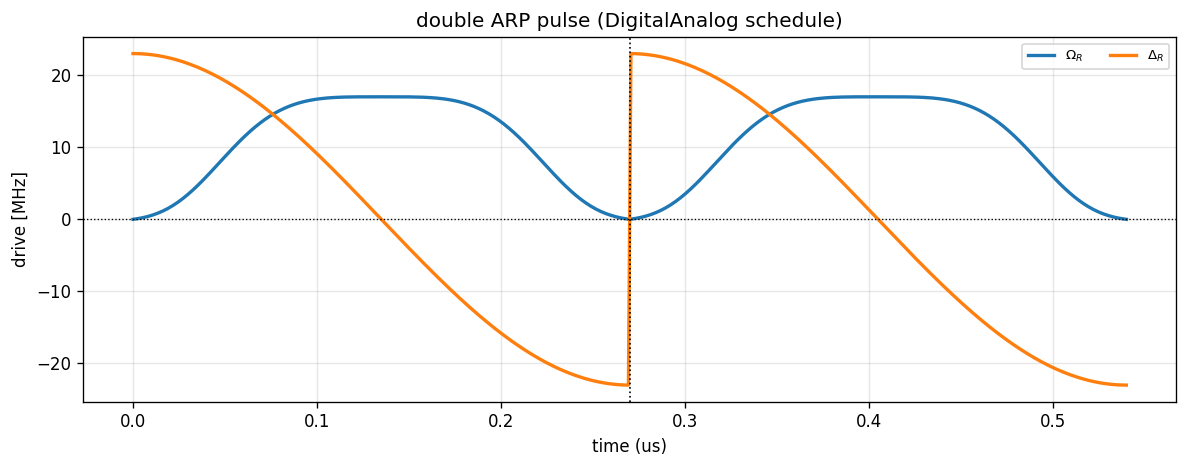

In [5]:
# Built-in protocol plot: the DigitalAnalog schedule actually simulated
# (Omega_R, Delta_R from get_drive_coefficients / pulse_traces), in MHz vs us.
# Replaces the former hand-written arp_omega/arp_delta figure; the sign of
# Delta_R follows the Hamiltonian convention H = ... - Delta_R n_r.
fig, ax = base_protocol.plot(
    system=base_system,
    unit_scale=1.0 / MHz,
    unit_label="MHz",
    time_scale=1.0 / us,
    time_label="time (us)",
    title="double ARP pulse (DigitalAnalog schedule)",
)
ax.axvline(0.5 * T_gate / us, color="k", ls=":", lw=1.0)  # mid-pulse reset
plt.show()

## 5. Population cycle(Fig. 2)

`B_POP/2π=100 MHz`:`|10>` 走 `|10>→|r0>→|10>`;`|11>` 主要走 `|11>→(|1r>+|r1>)/√2→|11>`,带小 `|rr>` leakage。

population traces elapsed: 1.74 s


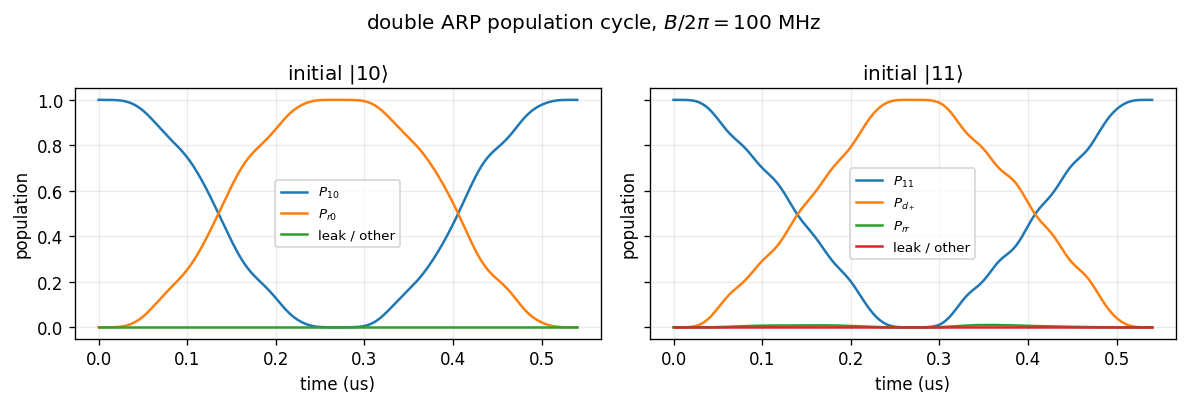

In [6]:
t_eval_pop = np.linspace(0.0, T_gate, N_STEPS + 1)

_t0 = time.perf_counter()
res_10 = run_exact_arp(ket10, B=B_POP, t_eval=t_eval_pop, n_steps=N_STEPS)
res_11 = run_exact_arp(ket11, B=B_POP, t_eval=t_eval_pop, n_steps=N_STEPS)
print(f"population traces elapsed: {time.perf_counter() - _t0:.2f} s")

states_10 = np.asarray(res_10.states)
states_11 = np.asarray(res_11.states)

P_10 = np.abs(states_10 @ ket10.conj()) ** 2
P_r0 = np.abs(states_10 @ ketr0.conj()) ** 2
P_dark_10 = 1.0 - P_10 - P_r0

P_11 = np.abs(states_11 @ ket11.conj()) ** 2
P_dplus = np.abs(states_11 @ ket_dplus.conj()) ** 2
P_rr = np.abs(states_11 @ ketrr.conj()) ** 2
P_dark_11 = 1.0 - P_11 - P_dplus - P_rr

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.4), sharex=True, sharey=True)
axes[0].plot(res_10.times / us, P_10, label=r"$P_{10}$")
axes[0].plot(res_10.times / us, P_r0, label=r"$P_{r0}$")
axes[0].plot(res_10.times / us, P_dark_10, label=r"leak / other")
axes[0].set_title(r"initial $|10\rangle$")

axes[1].plot(res_11.times / us, P_11, label=r"$P_{11}$")
axes[1].plot(res_11.times / us, P_dplus, label=r"$P_{d_+}$")
axes[1].plot(res_11.times / us, P_rr, label=r"$P_{rr}$")
axes[1].plot(res_11.times / us, P_dark_11, label=r"leak / other")
axes[1].set_title(r"initial $|11\rangle$")

for ax in axes:
    ax.set_xlabel("time (us)")
    ax.set_ylabel("population")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
fig.suptitle(rf"double ARP population cycle, $B/2\pi={B_POP / MHz:.0f}$ MHz")
fig.tight_layout()
plt.show()


## 6. Gate phases 和 Bell fidelity

`B_GATE/2π=3 GHz`:打印计算基返回概率、相位、Bell fidelity。coherent upper bound——无 Rydberg decay / intermediate scattering / Doppler / Stark 补偿。

In [7]:
_t0 = time.perf_counter()
U_eff = np.zeros((4, 4), dtype=complex)
for col, psi0 in enumerate(comp_states):
    psi_out = run_exact_arp(psi0, B=B_GATE, n_steps=N_STEPS).psi_final
    for row, bra in enumerate(comp_states):
        U_eff[row, col] = np.vdot(bra, psi_out)

phase_diag = np.angle(np.diag(U_eff))
diag_prob = np.abs(np.diag(U_eff)) ** 2
comp_return_prob = np.sum(np.abs(U_eff) ** 2, axis=0)
phi_ent = np.angle(np.exp(1j * (phase_diag[3] - phase_diag[1] - phase_diag[2] + phase_diag[0])))
F0 = bell_fidelity(B=B_GATE, n_steps=N_STEPS)

print(f"gate baseline elapsed: {time.perf_counter() - _t0:.2f} s")
print(f"B/2pi = {B_GATE / MHz:.0f} MHz, Bell fidelity = {F0:.8f}, infidelity = {1.0 - F0:.3e}")
print("state   diag_prob      comp_return      phase/pi")
for label, p_diag, p_comp, ph in zip(comp_labels, diag_prob, comp_return_prob, phase_diag / pi):
    print(f"|{label}>   {p_diag:10.8f}    {p_comp:10.8f}    {ph:10.6f}")
print(f"entangling phase/pi = {phi_ent / pi:.6f}")
print("\nEffective computational block:")
print(np.round(U_eff, 4))


gate baseline elapsed: 7.43 s
B/2pi = 3000 MHz, Bell fidelity = 0.99960552, infidelity = 3.945e-04
state   diag_prob      comp_return      phase/pi
|00>   1.00000000    1.00000000     -0.000000
|01>   0.99994223    0.99994223     -1.000000
|10>   0.99994223    0.99994223     -1.000000
|11>   0.99994645    0.99994645     -0.986203
entangling phase/pi = -0.986203

Effective computational block:
[[ 1.   -0.j      0.   +0.j      0.   +0.j      0.   +0.j    ]
 [ 0.   +0.j     -1.   -0.j      0.   +0.j      0.   +0.j    ]
 [ 0.   +0.j      0.   +0.j     -1.   -0.j      0.   +0.j    ]
 [ 0.   +0.j      0.   +0.j      0.   +0.j     -0.999-0.0433j]]


## 7. Fidelity sensitivity(`Omega`, detuning)

扫 Rabi 幅度 `Omega→sΩ`(±5%)和静态 detuning offset(±200 kHz)——论文展示 ARP robustness 的两个误差轴。

In [ ]:
omega_scales = np.linspace(0.95, 1.05, N_SCAN)
delta_offsets_hz = np.linspace(-0.2e6, 0.2e6, N_SCAN)

_t0 = time.perf_counter()
F_omega = np.asarray([
    bell_fidelity(B=B_GATE, omega_scale=float(scale), delta_offset=0.0, n_steps=N_STEPS)
    for scale in omega_scales
])
F_delta = np.asarray([
    bell_fidelity(B=B_GATE, omega_scale=1.0, delta_offset=2.0 * pi * float(offset_hz), n_steps=N_STEPS)
    for offset_hz in delta_offsets_hz
])
print(f"sensitivity scan elapsed: {time.perf_counter() - _t0:.2f} s")
print(f"Omega scan: min F = {F_omega.min():.8f}, max loss from center = {F_omega[len(F_omega)//2] - F_omega.min():.3e}")
print(f"Delta scan: min F = {F_delta.min():.8f}, max loss from center = {F_delta[len(F_delta)//2] - F_delta.min():.3e}")

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.4))
axes[0].plot((omega_scales - 1.0) * 100.0, F_omega, "o-", lw=1.8)
axes[0].axvline(0.0, color="k", ls=":", lw=1.0)
axes[0].set_xlabel(r"$\Omega$ variation (%)")
axes[0].set_ylabel("Bell fidelity")
axes[0].set_title(r"Rabi amplitude robustness")
axes[0].grid(alpha=0.25)

axes[1].plot(delta_offsets_hz / 1e3, F_delta, "s-", lw=1.8, color="tab:red")
axes[1].axvline(0.0, color="k", ls=":", lw=1.0)
axes[1].set_xlabel(r"detuning offset / $2\pi$ (kHz)")
axes[1].set_ylabel("Bell fidelity")
axes[1].set_title(r"detuning robustness")
axes[1].grid(alpha=0.25)

fig.suptitle(rf"double ARP CZ sensitivity, $B/2\pi={B_GATE / MHz:.0f}$ MHz")
fig.tight_layout()
plt.show()


## 8. 读图方式

- `B_POP=100 MHz` population plot 恢复 Fig. 2 直观图像。
- `B_GATE=3 GHz` fidelity plot 检查高 blockade 下 Bell fidelity 对 `Omega`/detuning 的鲁棒性。
- `B_GATE→100 MHz` 会增大 `|rr>` leakage、降 Bell fidelity——blockade 不够强,而非 pulse 形状错。
- 未含 decay / scattering / Doppler / Stark 补偿;加上后 coherent upper bound 会降到接近论文 full error model。

## 9. `our` seven-level system:同一个 double ARP

把上面 01r 的 ARP 映射到 Part A 用的 `our rb87_7` 七能级系统:

```python
RydbergSystem.from_lattice(Register.chain(2, spacing_um=3.0), "rb87_7", param_set="our", blackmanflag=True, detuning_sign=1)
```

用 `gate_cz.py` 的 `DoubleARPProtocol`(输出 `drive_420`、`drive_420_dag`、`lightshift_zero` channels):

- effective `Omega(t)` → 420nm amplitude scale `Omega(t)/system.meta("rabi_eff")`;
- effective `Delta(t)` → 420nm optical phase 的时间导数;
- `compensate_stark=True`:从本地矩阵块估 420 动态 differential Stark shift 并加入 chirp;
- `theta` 由 coherent overlaps 重新拟合(不再固定 `π`)。

注意 `our` 的 `rabi_eff/2π≈5 MHz`;直接套 Saffman 的 `Omega_max/2π=17 MHz` 会让 420nm amplitude scale >1——强驱动映射测试,不等于已为 `our` 重新优化的 ARP 门。

In [ ]:
from IPython.display import display, Markdown

from ryd_gate.protocols.gate_cz import DoubleARPProtocol
from ryd_gate.analysis.gate_metrics import average_gate_infidelity, error_budget, population_evolution
from ryd_gate.backends.exact import simulate as simulate_exact
from ryd_gate.core.operators import build_occ_operator

OUR_SPACING_UM = 3.0
OUR_N_STEPS = 80
OUR_OMEGA_MAX = Omega_max
OUR_DELTA_MAX = Delta_max
OUR_T_GATE = T_gate
OUR_SIGMA = sigma
OUR_COMPENSATE_STARK = True
OUR_STARK_COMPENSATION_SIGN = -1.0


def make_our_arp_protocol(theta=np.pi):
    return DoubleARPProtocol(
        omega_max=OUR_OMEGA_MAX,
        delta_max=OUR_DELTA_MAX,
        t_gate=OUR_T_GATE,
        sigma=OUR_SIGMA,
        theta=float(theta),
        n_steps=OUR_N_STEPS,
        compensate_stark=OUR_COMPENSATE_STARK,
        stark_compensation_sign=OUR_STARK_COMPENSATION_SIGN,
    )


def make_our_arp_system(protocol=None, **flags):
    return rg.RydbergSystem.from_lattice(
        Register.chain(2, spacing_um=OUR_SPACING_UM),
        "rb87_7",
        param_set="our",
        blackmanflag=True,
        detuning_sign=1,
        protocol=make_our_arp_protocol() if protocol is None else protocol,
        **flags,
    )


our_arp_protocol = make_our_arp_protocol()
our_system = make_our_arp_system(protocol=our_arp_protocol)
our_params = our_arp_protocol.unpack_params([], our_system)
print(f"our rb87_7 dim = {our_system.dim}")
print(f"rabi_eff/2pi = {our_system.meta('rabi_eff') / MHz:.3f} MHz")
print(f"ARP Omega_max/rabi_eff = {OUR_OMEGA_MAX / our_system.meta('rabi_eff'):.3f}")
print(f"V_ryd/2pi at {OUR_SPACING_UM} um = {our_system.meta('v_ryd') / MHz:.3f} MHz")
print(f"Stark compensation enabled = {OUR_COMPENSATE_STARK}, sign = {OUR_STARK_COMPENSATION_SIGN:+.0f}")

_t0 = time.perf_counter()
comp_basis = {label: our_system.product_state(label) for label in ("00", "01", "10", "11")}
phase_basis = {label: comp_basis[label] for label in ("00", "01", "11")}
phase_results = {}
phase_overlaps = {}
phase_comp_return = {}
phase_residuals = {"e1": 0.0, "e2": 0.0, "e3": 0.0, "ryd": 0.0, "ryd_garb": 0.0}
occ_ops = {
    "e1": build_occ_operator(2),
    "e2": build_occ_operator(3),
    "e3": build_occ_operator(4),
    "ryd": build_occ_operator(5),
    "ryd_garb": build_occ_operator(6),
}

for label, psi0 in phase_basis.items():
    res = simulate_exact(our_system, [], psi0)
    psi_f = res.psi_final
    phase_results[label] = psi_f
    phase_overlaps[label] = np.vdot(psi0, psi_f)
    phase_comp_return[label] = sum(abs(np.vdot(comp_basis[other], psi_f)) ** 2 for other in comp_basis)
    for key, op in occ_ops.items():
        phase_residuals[key] += float(np.real(np.vdot(psi_f, op @ psi_f))) / len(phase_basis)


def avg_fidelity_for_theta(theta):
    a00 = phase_overlaps["00"]
    a01 = np.exp(-1.0j * theta) * phase_overlaps["01"]
    a11 = np.exp(-1.0j * (2.0 * theta + np.pi)) * phase_overlaps["11"]
    return float((abs(a00 + 2.0 * a01 + a11) ** 2 + abs(a00) ** 2 + 2.0 * abs(a01) ** 2 + abs(a11) ** 2) / 20.0)

theta_grid = np.linspace(-np.pi, np.pi, 4001)
fid_grid = np.asarray([avg_fidelity_for_theta(theta) for theta in theta_grid])
theta_seed = float(theta_grid[int(np.argmax(fid_grid))])
theta_refine = np.linspace(theta_seed - 0.01, theta_seed + 0.01, 2001)
fid_refine = np.asarray([avg_fidelity_for_theta(theta) for theta in theta_refine])
theta_opt = float(theta_refine[int(np.argmax(fid_refine))])
our_avg_inf = 1.0 - float(fid_refine.max())
our_avg_inf_theta_pi = 1.0 - avg_fidelity_for_theta(np.pi)

our_arp_protocol = make_our_arp_protocol(theta=theta_opt)
our_system = make_our_arp_system(protocol=our_arp_protocol)

print(f"our coherent average infidelity at theta=pi  = {our_avg_inf_theta_pi:.6e}")
print(f"optimized theta = {theta_opt:.6f} rad ({theta_opt / np.pi:.6f} pi)")
print(f"our coherent average infidelity optimized = {our_avg_inf:.6e}; elapsed = {time.perf_counter() - _t0:.2f} s")
print("return probabilities:", {k: float(abs(v) ** 2) for k, v in phase_overlaps.items()})
print("computational return:", {k: float(v) for k, v in phase_comp_return.items()})
print("final residual populations:", {k: float(v) for k, v in phase_residuals.items()})

pops = population_evolution(our_system, our_arp_protocol, [], "SSS-0")
time_ns = np.asarray(pops["t_list"]) * 1e9

fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.plot(time_ns, (pops["e1"] + pops["e2"] + pops["e3"]) / 2.0, lw=1.6, label="intermediate")
ax.plot(time_ns, pops["ryd"] / 2.0, lw=1.6, label="Rydberg |r1>")
ax.plot(time_ns, pops["ryd_garb"] / 2.0, lw=1.6, label="garbage Rydberg |r2>")
ax.set_xlabel("time (ns)")
ax.set_ylabel("SSS-0 averaged population per atom")
ax.set_title("our rb87_7 Stark-compensated double-ARP population evolution")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## 10. 为什么 `our` 结果不是相位门:动态 Stark 诊断

Saffman 参数是给有效二能级写的;映射到 `our rb87_7` 后 `Omega_max/2π=17 MHz` 需把 420nm amplitude scale 放大到 `Omega_max/rabi_eff≈3.4`,产生很大的 `|1>` AC Stark shift。下面用本地矩阵块做二阶消元估算:若 differential Stark shift 大于 detuning sweep range,ARP 没穿过真实 avoided crossing,末态不回计算基,故不是相位门。

In [ ]:
H0_local = our_system.blocks.get("H_const").matrix
H420_local = our_system.blocks.get("drive_420").matrix
H1013_local = our_system.blocks.get("H_1013").matrix
mid_energies = np.real(np.diag(H0_local)[2:5])
amp_peak = OUR_OMEGA_MAX / our_system.meta("rabi_eff")

stark_1_peak = -sum(abs(amp_peak * H420_local[e, 1]) ** 2 / mid_energies[e - 2] for e in (2, 3, 4))
stark_r_peak = -sum(abs(H1013_local[5, e]) ** 2 / mid_energies[e - 2] for e in (2, 3, 4))
g_eff_peak = -sum(H1013_local[5, e] * amp_peak * H420_local[e, 1] / mid_energies[e - 2] for e in (2, 3, 4))
g_garb_peak = -sum(H1013_local[6, e] * amp_peak * H420_local[e, 1] / mid_energies[e - 2] for e in (2, 3, 4))
differential_stark = stark_r_peak - stark_1_peak

print(f"effective Omega_peak/2pi from local blocks = {2 * abs(g_eff_peak) / MHz:.3f} MHz")
print(f"garbage Rydberg coupling/2pi         = {2 * abs(g_garb_peak) / MHz:.3f} MHz")
print(f"|1> Stark shift /2pi                 = {stark_1_peak / MHz:.3f} MHz")
print(f"|r> Stark shift /2pi                 = {stark_r_peak / MHz:.3f} MHz")
print(f"differential Stark (r-1)/2pi          = {differential_stark / MHz:.3f} MHz")
print(f"ARP desired detuning at peak /2pi     = {our_arp_protocol.detuning(T_gate / 4, our_params) / MHz:.3f} MHz")
print(f"compensated chirp at peak /2pi        = {our_arp_protocol.chirp_detuning(T_gate / 4, our_params) / MHz:.3f} MHz")
print(f"chirp + Stark at peak /2pi            = {(our_arp_protocol.chirp_detuning(T_gate / 4, our_params) + our_arp_protocol.stark_shift(T_gate / 4, our_params)) / MHz:.3f} MHz")
print(f"ARP detuning sweep range /2pi         = ±{OUR_DELTA_MAX / MHz:.3f} MHz")


In [ ]:
# Deterministic noise diagnose, mirroring cz_gate_validation_and_errors.ipynb.
# This is intentionally a compact table: no Monte Carlo dephasing/position sampling here.

RUN_OUR_NOISE_DIAGNOSE = False
OUR_BUDGET_STATES = ["01", "11"]

if RUN_OUR_NOISE_DIAGNOSE and our_avg_inf < 1e-2:
    noise_rows = []

    _t0 = time.perf_counter()
    system_ryd = make_our_arp_system(enable_rydberg_decay=True)
    inf_ryd = average_gate_infidelity(system_ryd, our_arp_protocol, [])
    budget_ryd = error_budget(system_ryd, our_arp_protocol, [], initial_states=OUR_BUDGET_STATES)["rydberg_decay"]
    noise_rows.append(("rydberg_decay", inf_ryd, budget_ryd))

    system_mid = make_our_arp_system(enable_intermediate_decay=True)
    inf_mid = average_gate_infidelity(system_mid, our_arp_protocol, [])
    budget_mid = error_budget(system_mid, our_arp_protocol, [], initial_states=OUR_BUDGET_STATES)["intermediate_decay"]
    noise_rows.append(("intermediate_decay", inf_mid, budget_mid))

    system_mid_no0 = make_our_arp_system(enable_intermediate_decay=True, enable_0_scattering=False)
    inf_mid_no0 = average_gate_infidelity(system_mid_no0, our_arp_protocol, [])
    zero_scatter_extra = max(0.0, float(inf_mid - inf_mid_no0))

    system_all = make_our_arp_system(
        enable_rydberg_decay=True,
        enable_intermediate_decay=True,
        enable_polarization_leakage=True,
    )
    inf_all = average_gate_infidelity(system_all, our_arp_protocol, [])
    budget_all = error_budget(system_all, our_arp_protocol, [], initial_states=OUR_BUDGET_STATES)
    combined = {
        "XYZ": budget_all["rydberg_decay"]["XYZ"] + budget_all["intermediate_decay"]["XYZ"] + budget_all["polarization_leakage"]["XYZ"],
        "AL": budget_all["rydberg_decay"]["AL"] + budget_all["intermediate_decay"]["AL"] + budget_all["polarization_leakage"]["AL"],
        "LG": budget_all["rydberg_decay"]["LG"] + budget_all["intermediate_decay"]["LG"] + budget_all["polarization_leakage"]["LG"],
    }
    noise_rows.append(("all_deterministic", inf_all, combined))

    text = "| source | average infidelity | XYZ | AL | LG | residual |\n|---|---:|---:|---:|---:|---:|\n"
    for label, inf, budget in noise_rows:
        xyz = float(budget.get("XYZ", 0.0))
        al = float(budget.get("AL", 0.0))
        lg = float(budget.get("LG", 0.0))
        residual = float(inf) - (xyz + al + lg)
        if label == "intermediate_decay":
            residual -= zero_scatter_extra
        text += f"| {label} | {float(inf):.6e} | {xyz:.6e} | {al:.6e} | {lg:.6e} | {residual:.6e} |\n"
    text += f"\nIntermediate `|0>` scattering extra infidelity: `{zero_scatter_extra:.6e}`.  \n"
    text += f"Noise diagnose elapsed: `{time.perf_counter() - _t0:.2f} s`."
    display(Markdown(text))
else:
    print("Noise diagnose skipped: first retune the coherent ARP gate so it is actually a phase gate. Set RUN_OUR_NOISE_DIAGNOSE=True after our_avg_inf < 1e-2.")
